In [1]:


import skrf as rf
import matplotlib.pyplot as plt

ntwk = rf.Network('Alexander_implant_Copper_pHANTOM_to_Horn-50CM.s2p')

fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Reflection (S11, S22)
ntwk.plot_s_db(m=0, n=0, ax=axs[0], label='S11')
ntwk.plot_s_db(m=1, n=1, ax=axs[0], label='S22')
axs[0].set_title('Reflection Coefficients')
axs[0].legend()
axs[0].grid()

# Transmission (S21, S12)
ntwk.plot_s_db(m=1, n=0, ax=axs[1], label='S21')
ntwk.plot_s_db(m=0, n=1, ax=axs[1], label='S12')
axs[1].set_title('Transmission Coefficients')
axs[1].legend()
axs[1].grid()





plt.tight_layout()

ModuleNotFoundError: No module named 'skrf'

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Full view
ntwk.plot_s_db(ax=ax[0])
ax[0].set_xlim(6e6, 1.2e9)
ax[0].axvspan(800e6, 900e6, color='yellow', alpha=0.3)
ax[0].set_title("Full Band")

# Zoomed view (your region of interest)
ntwk.plot_s_db(ax=ax[1])
ax[1].set_xlim(600e6, 1200e6)
ax[1].set_title("Focused Band (600–1200 MHz)")
ax[1].grid()

plt.tight_layout()

In [ ]:
import skrf as rf

ntwk2 = rf.Network('Alexander_implant_Copper_space_to_Horn-50CM.s2p')

print(ntwk2)
ntwk2.plot_s_db()

In [3]:
import skrf as rf
import matplotlib.pyplot as plt

ntwk2 = rf.Network('Alexander_implant_Copper_space_to_Horn-50CM.s2p')

fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Reflection (S11, S22)
ntwk2.plot_s_db(m=0, n=0, ax=axs[0], label='S11')
ntwk2.plot_s_db(m=1, n=1, ax=axs[0], label='S22')
axs[0].set_title('Reflection Coefficients')
axs[0].legend()
axs[0].grid()

# Transmission (S21, S12)
ntwk2.plot_s_db(m=1, n=0, ax=axs[1], label='S21')
ntwk2.plot_s_db(m=0, n=1, ax=axs[1], label='S12')
axs[1].set_title('Transmission Coefficients')
axs[1].legend()
axs[1].grid()





plt.tight_layout()

ModuleNotFoundError: No module named 'skrf'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6))

# Full view
ntwk2.plot_s_db(ax=ax[0])
ax[0].set_xlim(6e6, 1.2e9)
ax[0].axvspan(800e6, 900e6, color='yellow', alpha=0.3)
ax[0].set_title("Full Band")

# Zoomed view (your region of interest)
ntwk2.plot_s_db(ax=ax[1])
ax[1].set_xlim(800e6, 900e6)
ax[1].set_title("Focused Band (800–900 MHz)")
ax[1].grid()

plt.tight_layout()

In [ ]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# USER INPUTS
# -----------------------------

d = 0.5                      # distance in meters
Gr = 6                       # receiver gain in dB
Pt = 0                       # transmitted power in dB
c = 3e8                      # speed of light (m/s)

# -----------------------------
# EXTRACT DATA
# -----------------------------
freq = ntwk.f                      # frequency in Hz
s21_db = ntwk.s_db[:, 1, 0]        # S21 in dB

# -----------------------------
# FILTER 0.6–1.2 GHz
# -----------------------------
mask = (freq >= 600e6) & (freq <= 1200e6)
freq = freq[mask]
s21_db = s21_db[mask]

# -----------------------------
# RECEIVED POWER
# -----------------------------
Pr = s21_db  # since Pt = 0 dB

# -----------------------------
# FREE SPACE PATH LOSS (FSPL)
# -----------------------------
fspl = 20*np.log10(d) + 20*np.log10(freq) + 20*np.log10(4*np.pi / c)

# -----------------------------
# CALCULATE Gt
# -----------------------------
Gt = Pr - Pt + fspl - Gr
# since Pt = 0 → Gt = Pr + fspl - Gr

# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

plt.plot(freq / 1e9, Gt, label='Realised Gain (dBi)', color='blue')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Realised Gain (dBi)')
plt.title('Realised Gain vs Frequency')
plt.grid(True)
plt.legend()

plt.tight_layout()

# Save high-quality outputs
plt.savefig("Gain_plot.png", dpi=300, bbox_inches='tight')

plt.show()

ModuleNotFoundError: No module named 'skrf'

In [ ]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("CopperUpdatedPhantom_rlzGain.txt")
x3 = data[:, 0]
y3 = data[:, 1]
# -----------------------------
# USER INPUTS
# -----------------------------

d = 0.5                      # distance in meters
Gr = 6                       # receiver gain in dB
Pt = 0                       # transmitted power in dB
c = 3e8                      # speed of light (m/s)

# -----------------------------
# EXTRACT DATA
# -----------------------------
freq = ntwk.f                      # frequency in Hz
s21_db = ntwk.s_db[:, 1, 0]        # S21 in dB

# -----------------------------
# FILTER 0.6–1.2 GHz
# -----------------------------
mask = (freq >= 00e6) & (freq <= 1600e6)
freq = freq[mask]
s21_db = s21_db[mask]

# -----------------------------
# RECEIVED POWER
# -----------------------------
Pr = s21_db  # since Pt = 0 dB

# -----------------------------
# FREE SPACE PATH LOSS (FSPL)
# -----------------------------
fspl = 20*np.log10(d) + 20*np.log10(freq) + 20*np.log10(4*np.pi / c)

# -----------------------------
# CALCULATE Gt
# -----------------------------
Gt = Pr - Pt + fspl - Gr
# since Pt = 0 → Gt = Pr + fspl - Gr



# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

# Copper curve (highlighted)
plt.plot(
    x3, y3,
    color="black",
    linewidth=2,
    label="CST Simulation"
)

plt.xlim(0.6, 1.2) #Limits are 0.1 - 1.5/6
plt.ylim(-40, -18)

plt.plot(freq / 1e9, Gt, label='VNA Measurement', color='blue')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Realised Gain (dBi)')
plt.title('Realised Gain vs Frequency for Copper in Phantom')
plt.grid(True)
plt.legend()

# Grid (subtle)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend (clean placement)
plt.legend(fontsize=9, loc='best', frameon=False)

plt.tight_layout()

# Save high-quality outputs
plt.savefig("Sim_and_Measurements_Gain_plot.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import skrf as rf
import matplotlib.pyplot as plt

ntwk2 = rf.Network('CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p')

fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Reflection (S11, S22)
ntwk2.plot_s_db(m=0, n=0, ax=axs[0], label='S11')
ntwk2.plot_s_db(m=1, n=1, ax=axs[0], label='S22')
axs[0].set_title('Reflection Coefficients')
axs[0].legend()
axs[0].grid()

# Transmission (S21, S12)
ntwk2.plot_s_db(m=1, n=0, ax=axs[1], label='S21')
ntwk2.plot_s_db(m=0, n=1, ax=axs[1], label='S12')
axs[1].set_title('Transmission Coefficients')
axs[1].legend()
axs[1].grid()





plt.tight_layout()

In [ ]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt

simdata = np.loadtxt("CST_Copper_PhantomRemoved_Farfield_realisedGain.txt")
x3 = simdata[:, 0]
y3 = simdata[:, 1]

measured
# -----------------------------
# USER INPUTS
# -----------------------------

d = 0.5                      # distance in meters
Gr = 6                       # receiver gain in dB
Pt = 0                       # transmitted power in dB
c = 3e8                      # speed of light (m/s)

# -----------------------------
# EXTRACT DATA
# -----------------------------

ntwk = rf.Network('INSERTFILE.s2p')
freq = ntwk.f                      # frequency in Hz
s21_db = ntwk.s_db[:, 1, 0]        # S21 in dB

# -----------------------------
# FILTER 0.6–1.2 GHz
# -----------------------------
mask = (freq >= 00e6) & (freq <= 1600e6)
freq = freq[mask]
s21_db = s21_db[mask]

# -----------------------------
# RECEIVED POWER
# -----------------------------
Pr = s21_db  # since Pt = 0 dB

# -----------------------------
# FREE SPACE PATH LOSS (FSPL)
# -----------------------------
fspl = 20*np.log10(d) + 20*np.log10(freq) + 20*np.log10(4*np.pi / c)

# -----------------------------
# CALCULATE Gt
# -----------------------------
Gt = Pr - Pt + fspl - Gr
# since Pt = 0 → Gt = Pr + fspl - Gr



# -----------------------------
# PLOT RESULTS
# -----------------------------
plt.figure(figsize=(8,6))

# Copper curve (highlighted)
plt.plot(
    x3, y3,
    color="black",
    linewidth=2,
    label="CST Simulation"
)

plt.xlim(0.6, 1.2) #Limits are 0.1 - 1.5/6
plt.ylim(-40, -18)

plt.plot(freq / 1e9, Gt, label='VNA Measurement', color='blue')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Realised Gain (dBi)')
plt.title('Realised Gain vs Frequency for Copper in Free Space')
plt.grid(True)
plt.legend()

# Grid (subtle)
plt.grid(True, linestyle='--', alpha=0.5)

# Ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Legend (clean placement)
plt.legend(fontsize=9, loc='best', frameon=False)

plt.tight_layout()

# Save high-quality outputs
plt.savefig("Sim_and_Measurements_Gain_plot.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
import skrf as rf
import numpy as np
import matplotlib.pyplot as plt


picodata = load_data("CST_Copper_PhantomRemoved_S11.txt")

x3 = picodata[:, 0]
y3 = picodata[:, 1]

plt.plot(
    x3, y3,
    color="black",
    linewidth=2.5,
    linestyle="--",
    label="CST Simulation"
)
ntwk3 = rf.Network('CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p')

fig, axs = plt.subplots(2, 1, figsize=(8, 6))

# Reflection (S11, S22)
ntwk3.plot_s_db(m=0, n=0, ax=axs[0], label='S11')
#ntwk3.plot_s_db(m=1, n=1, ax=axs[0], label='S22')
axs[0].set_title('Reflection Coefficient')
axs[0].legend()
axs[0].grid()

# Transmission (S21, S12)
#ntwk2.plot_s_db(m=1, n=0, ax=axs[1], label='S21')
#ntwk2.plot_s_db(m=0, n=1, ax=axs[1], label='S12')
#axs[1].set_title('Transmission Coefficients')
#axs[1].legend()
#axs[1].grid()

plt.tight_layout()


ModuleNotFoundError: No module named 'skrf'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
txt_file = "CST_Copper_PhantomRemoved_S11.txt"
s2p_file = "CopperFreespaceLOS_7thMay10MHzto6Ghz.s2p"

# -----------------------------
# Load CST TXT file
# Assumes:
# Column 1 = Frequency
# Column 2 = S11 magnitude (dB)
# -----------------------------
txt_data = np.loadtxt(txt_file)

freq_txt = txt_data[:, 0]
s11_txt = txt_data[:, 1]

# Convert frequency to GHz if needed
# Uncomment if frequencies are in Hz
# freq_txt = freq_txt / 1e9

# -----------------------------
# Load Touchstone S2P file
# -----------------------------
freq_s2p = []
s11_s2p_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip comments and option lines
        if not line or line.startswith('!'):
            continue

        # Parse option line
        if line.startswith('#'):
            option_line = line.upper()

            # Determine frequency unit
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Determine data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = line.split()

        # Standard S2P has:
        # freq S11 S21 S12 S22
        # each S-param has 2 values depending on format
        values = [float(v) for v in values]

        freq = values[0] * freq_scale

        if data_format == 'DB':
            s11_db = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11_db = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11_db = 20 * np.log10(mag)

        freq_s2p.append(freq)
        s11_s2p_db.append(s11_db)

freq_s2p = np.array(freq_s2p)
s11_s2p_db = np.array(s11_s2p_db)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq_txt, s11_txt,
         label='CST Simulation',
         linewidth=2)

plt.plot(freq_s2p, s11_s2p_db,
         label='VNA Measurement',
         linewidth=2)

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 Comparison for Copper Meandered Dipole Antenna in Freespace LOS (No phantom)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Sim_and_Measurements_S11_plot.png", dpi=300, bbox_inches='tight')


plt.show()

FileNotFoundError: CST_Copper_PhantomRemoved_S11.txt not found.

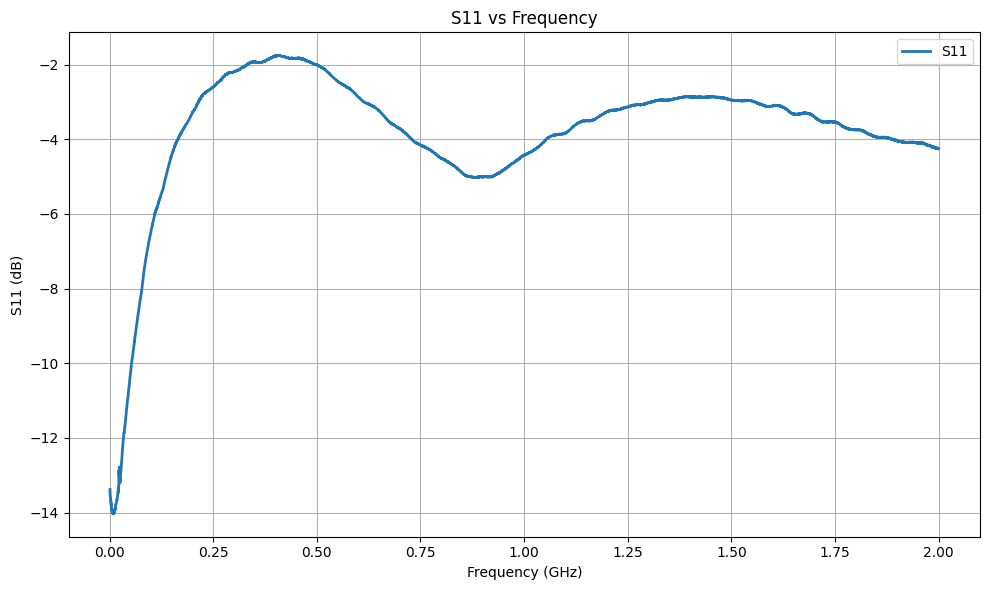

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Touchstone file
# ------------------------------------------------
s2p_file = r"Alexander_implant_Copper_pHANTOM_to_Horn-50CM.s2p"

# ------------------------------------------------
# Read S2P file
# ------------------------------------------------
freq = []
s11_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip empty lines and comments
        if not line or line.startswith('!'):
            continue

        # Parse options line
        if line.startswith('#'):
            option_line = line.upper()

            # Frequency scaling
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = [float(v) for v in line.split()]

        # Frequency in GHz
        f_ghz = values[0] * freq_scale

        # Extract S11
        if data_format == 'DB':
            s11 = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11 = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11 = 20 * np.log10(mag)

        freq.append(f_ghz)
        s11_db.append(s11)

freq = np.array(freq)
s11_db = np.array(s11_db)

# ------------------------------------------------
# Plot S11
# ------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq, s11_db,
         linewidth=2,
         label='S11')

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 vs Frequency')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("Trial1_CopperinPhantomS11_plot.png", dpi=300, bbox_inches='tight')

plt.show()

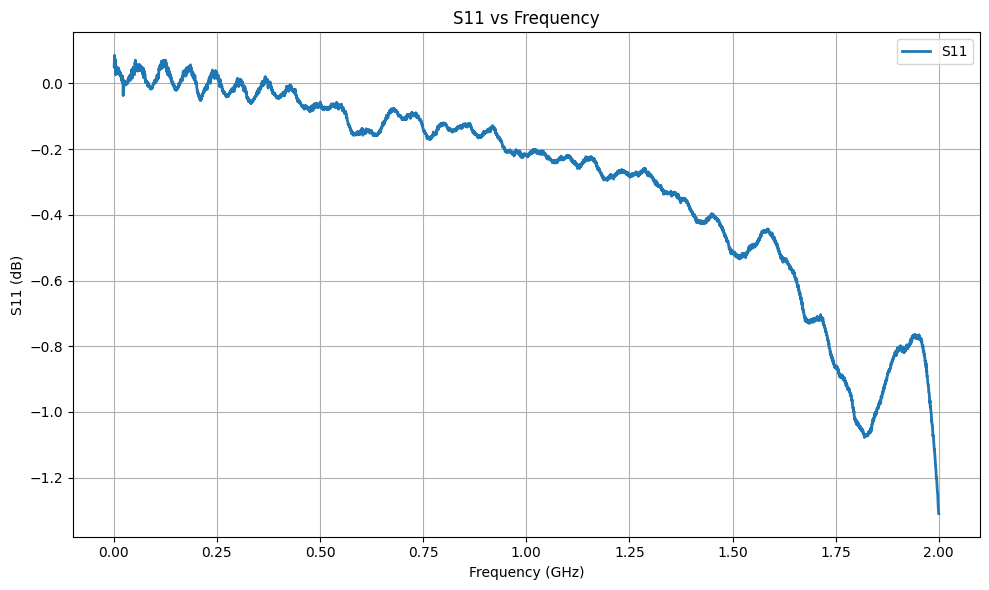

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Touchstone file
# ------------------------------------------------
s2p_file = r"Alexander_implant_Copper_space_to_Horn-50CM.s2p"

# ------------------------------------------------
# Read S2P file
# ------------------------------------------------
freq = []
s11_db = []

with open(s2p_file, 'r') as f:
    for line in f:
        line = line.strip()

        # Skip empty lines and comments
        if not line or line.startswith('!'):
            continue

        # Parse options line
        if line.startswith('#'):
            option_line = line.upper()

            # Frequency scaling
            if 'GHZ' in option_line:
                freq_scale = 1
            elif 'MHZ' in option_line:
                freq_scale = 1e-3
            elif 'KHZ' in option_line:
                freq_scale = 1e-6
            elif 'HZ' in option_line:
                freq_scale = 1e-9
            else:
                freq_scale = 1

            # Data format
            if 'DB' in option_line:
                data_format = 'DB'
            elif 'MA' in option_line:
                data_format = 'MA'
            elif 'RI' in option_line:
                data_format = 'RI'

            continue

        values = [float(v) for v in line.split()]

        # Frequency in GHz
        f_ghz = values[0] * freq_scale

        # Extract S11
        if data_format == 'DB':
            s11 = values[1]

        elif data_format == 'MA':
            mag = values[1]
            s11 = 20 * np.log10(mag)

        elif data_format == 'RI':
            real = values[1]
            imag = values[2]
            mag = np.sqrt(real**2 + imag**2)
            s11 = 20 * np.log10(mag)

        freq.append(f_ghz)
        s11_db.append(s11)

freq = np.array(freq)
s11_db = np.array(s11_db)

# ------------------------------------------------
# Plot S11
# ------------------------------------------------
plt.figure(figsize=(10, 6))

plt.plot(freq, s11_db,
         linewidth=2,
         label='S11')

plt.xlabel('Frequency (GHz)')
plt.ylabel('S11 (dB)')
plt.title('S11 vs Frequency')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

Found 14 s2p files.
Saved: copper_Dipole_F_10M_3000MHz_thin_pushed_edge_S11_plot.png


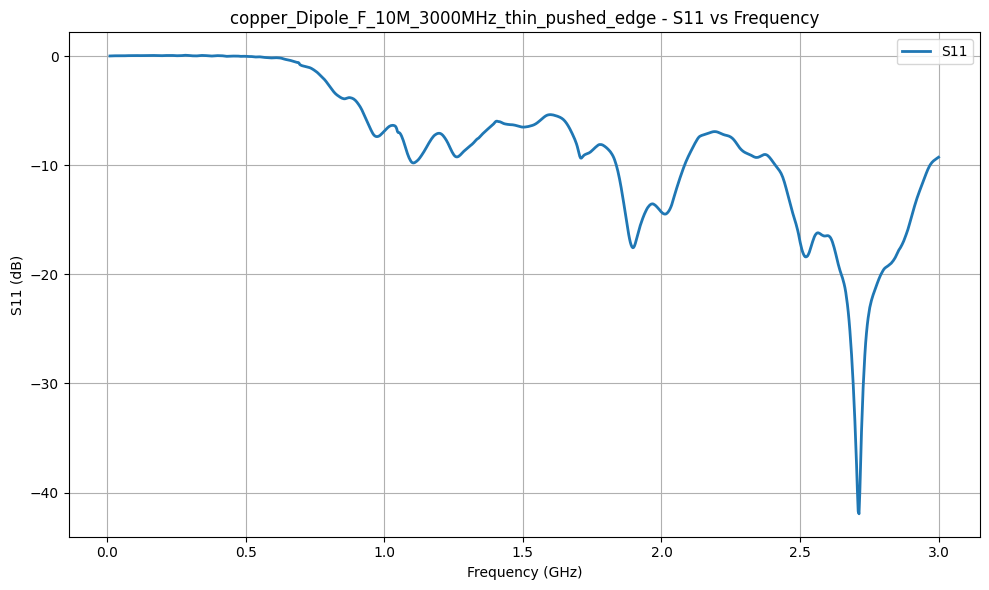

Saved: copper_Dipole_F_10M_3000MHz_block sqashed 2_S11_plot.png


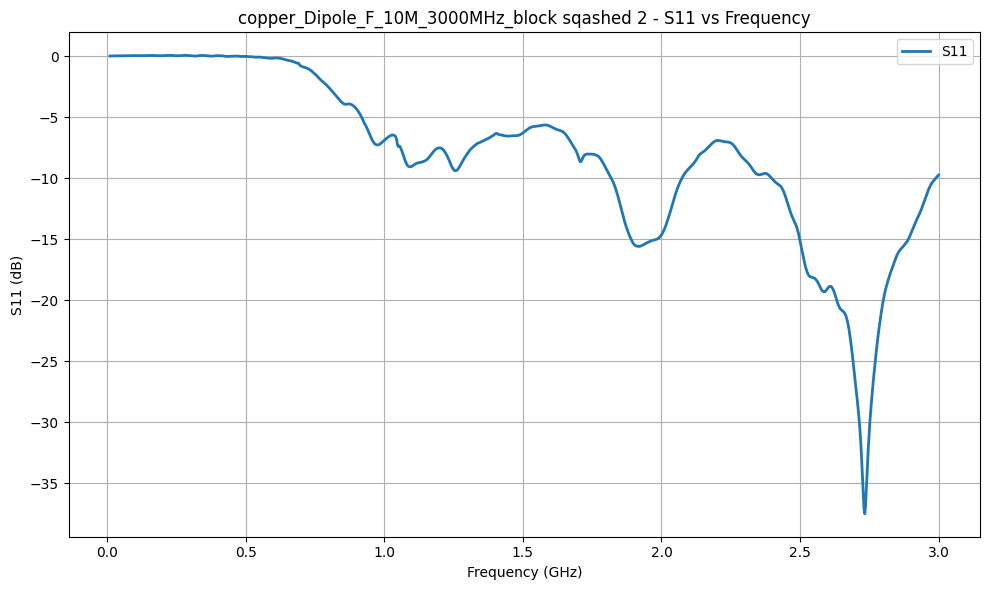

Saved: Copper_Dipole_F_10M_3000MHz_thin_pushed_S11_plot.png


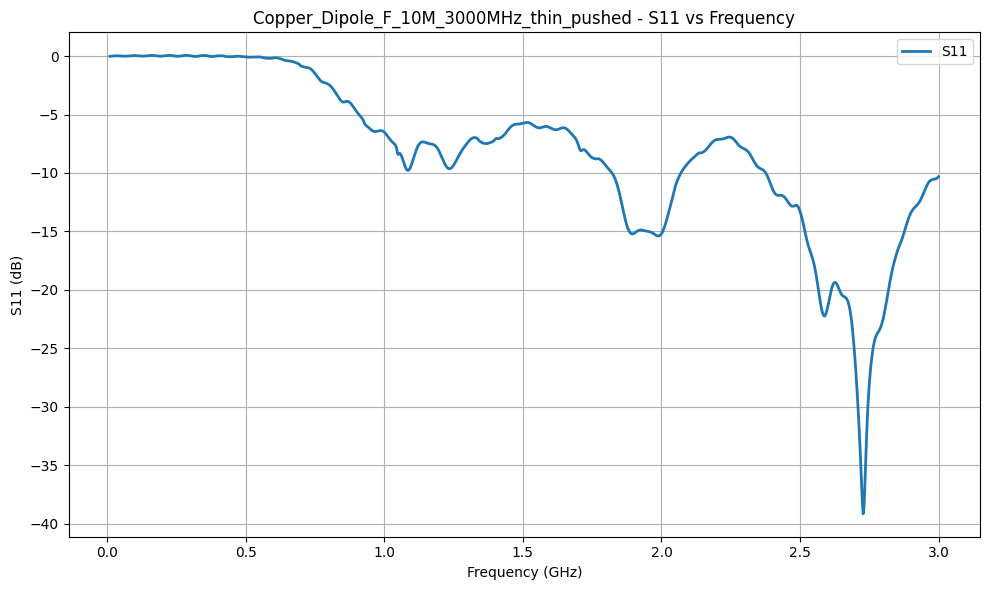

Saved: pedot_Dipole_F_10M_3000MHz_thin_pushed_edge_S11_plot.png


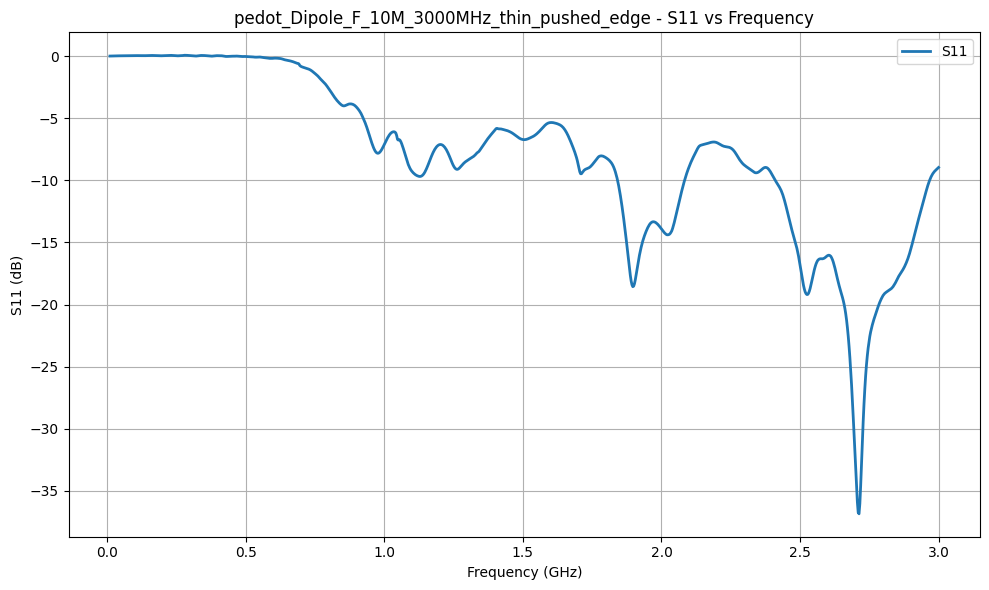

Saved: pedot_Dipole_F_10M_3000MHz_thick block sqashed 1_S11_plot.png


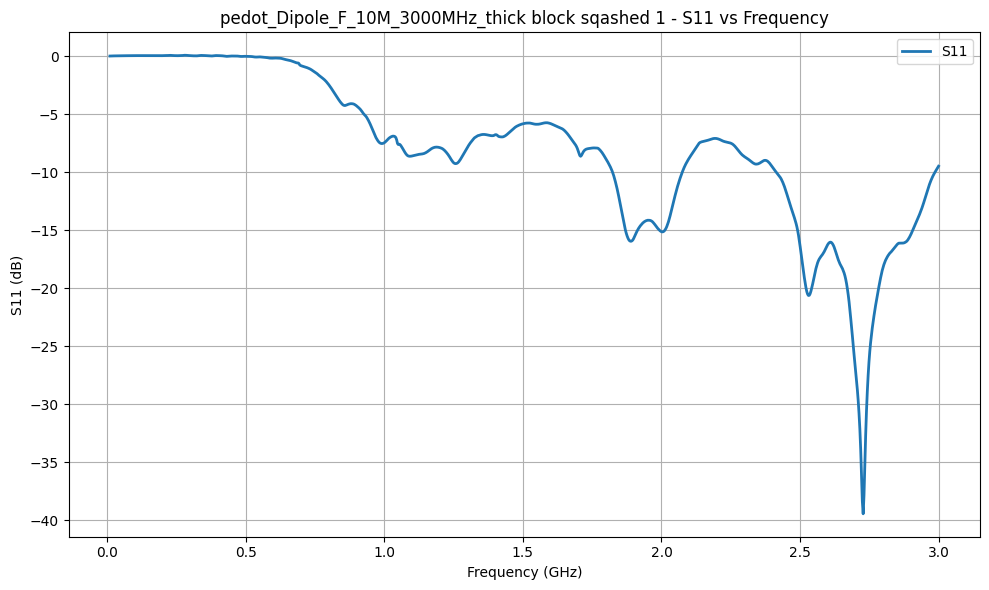

Saved: copper_Dipole_F_10M_3000MHz_block sqashed_S11_plot.png


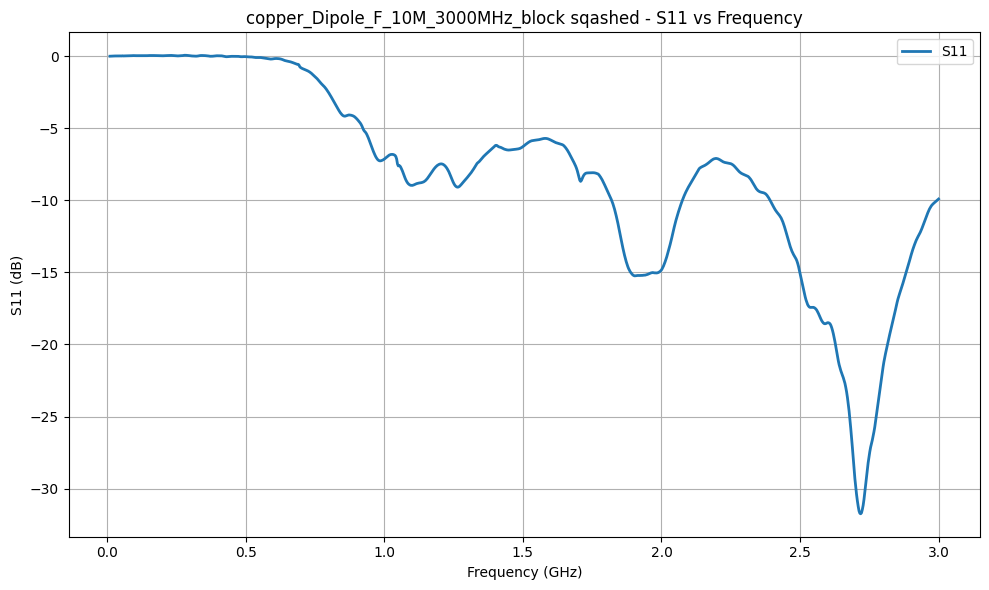

Saved: pedot_Dipole_F_10M_3000MHz_block sqashed 1_S11_plot.png


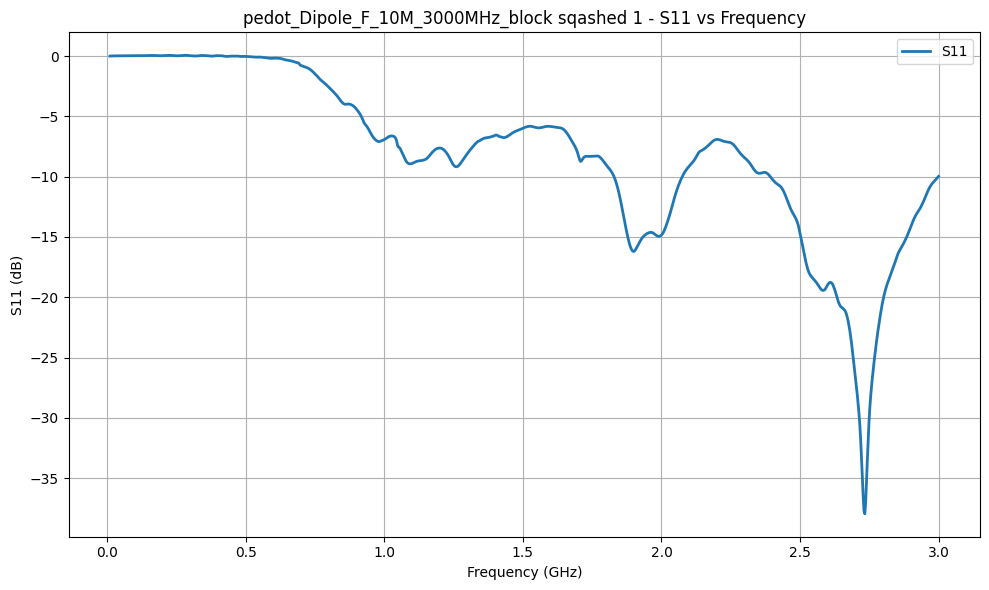

Saved: Copper_Dipole_Ave10,F_500M_1500MHz_S11_plot.png


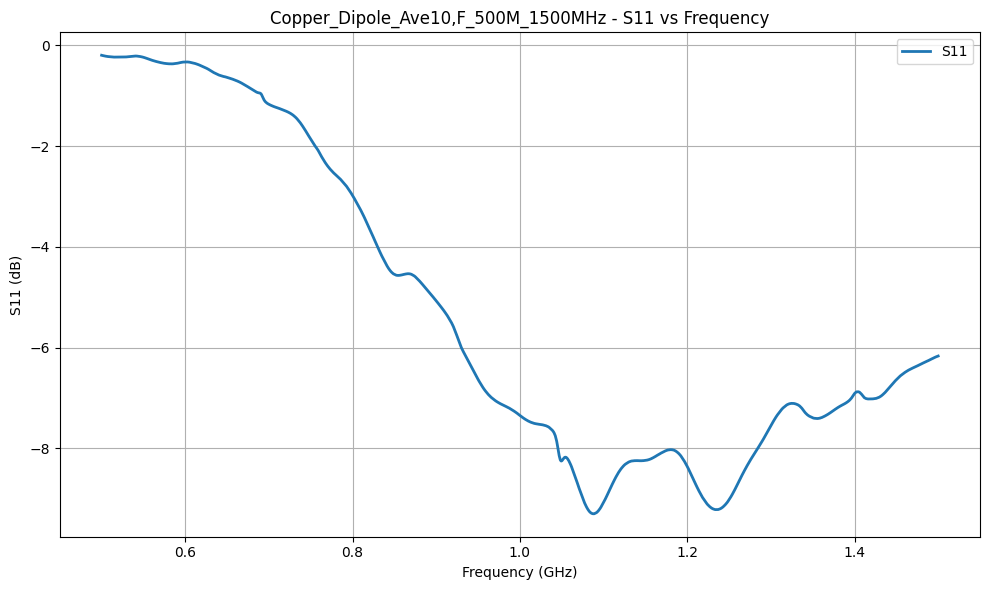

Saved: Copper_Dipole_Ave8,F_10M_6000MHz_think_S11_plot.png


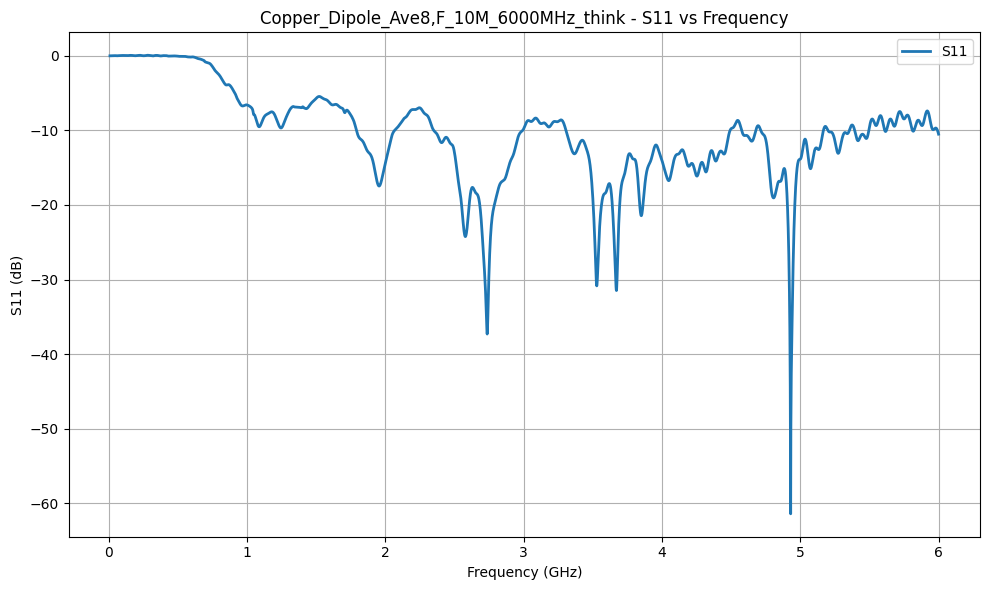

Saved: Alexander_implant_Copper_space_to_Horn-50CM_S11_plot.png


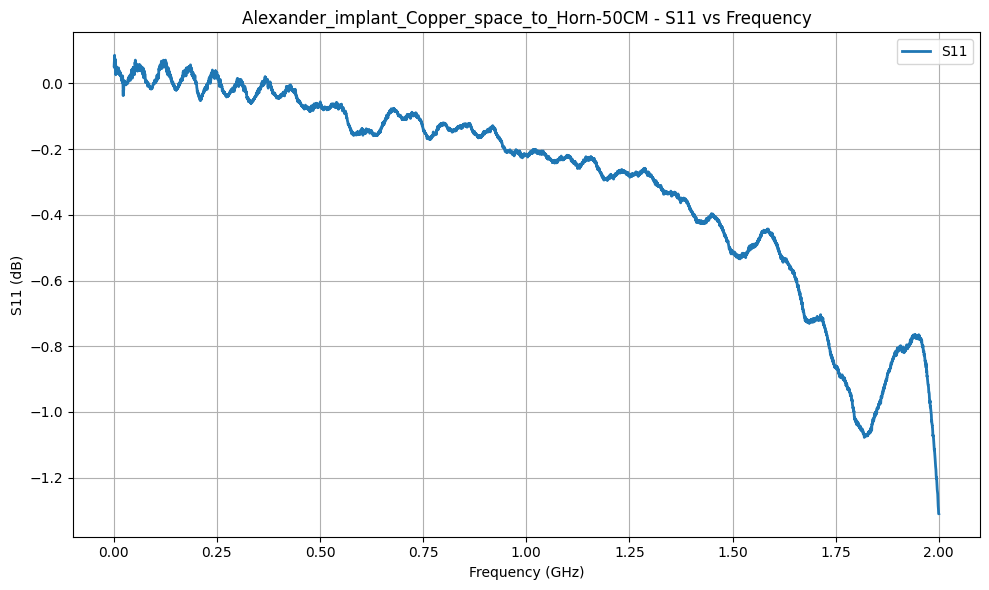

Saved: pedot_Dipole_F_10M_3000MHz_block sqashed 2_S11_plot.png


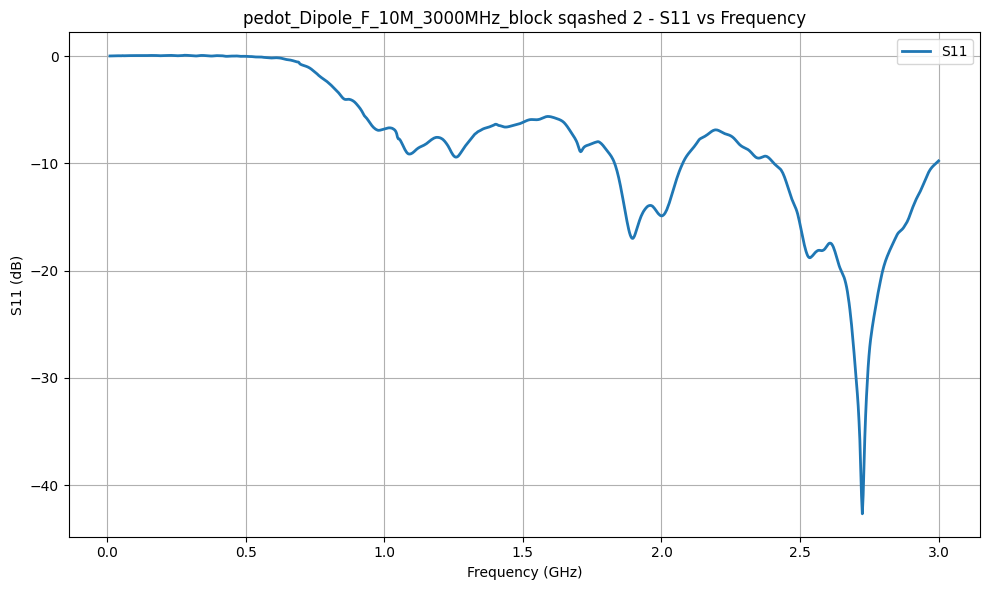

FileNotFoundError: [Errno 2] No such file or directory: 'Alexander_implant_Copper_pHANTOM_to_Horn-50CM.s2p'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ------------------------------------------------
# Find all .s2p files in Google Colab working directory
# ------------------------------------------------
s2p_files = glob.glob("*.s2p")

if not s2p_files:
    print("No .s2p files found.")
else:
    print(f"Found {len(s2p_files)} s2p files.")

# ------------------------------------------------
# Process each S2P file
# ------------------------------------------------
for s2p_file in s2p_files:

    freq = []
    s11_db = []

    # Default values
    freq_scale = 1
    data_format = 'DB'

    # ------------------------------------------------
    # Read S2P file
    # ------------------------------------------------
    with open(s2p_file, 'r') as f:
        for line in f:
            line = line.strip()

            # Skip empty lines and comments
            if not line or line.startswith('!'):
                continue

            # Parse options line
            if line.startswith('#'):
                option_line = line.upper()

                # Frequency scaling
                if 'GHZ' in option_line:
                    freq_scale = 1
                elif 'MHZ' in option_line:
                    freq_scale = 1e-3
                elif 'KHZ' in option_line:
                    freq_scale = 1e-6
                elif 'HZ' in option_line:
                    freq_scale = 1e-9

                # Data format
                if 'DB' in option_line:
                    data_format = 'DB'
                elif 'MA' in option_line:
                    data_format = 'MA'
                elif 'RI' in option_line:
                    data_format = 'RI'

                continue

            values = [float(v) for v in line.split()]

            # Frequency in GHz
            f_ghz = values[0] * freq_scale

            # Extract S11
            if data_format == 'DB':
                s11 = values[1]

            elif data_format == 'MA':
                mag = values[1]
                s11 = 20 * np.log10(mag)

            elif data_format == 'RI':
                real = values[1]
                imag = values[2]
                mag = np.sqrt(real**2 + imag**2)
                s11 = 20 * np.log10(mag)

            freq.append(f_ghz)
            s11_db.append(s11)

    freq = np.array(freq)
    s11_db = np.array(s11_db)

    # ------------------------------------------------
    # Create plot
    # ------------------------------------------------
    plt.figure(figsize=(10, 6))

    plt.plot(freq, s11_db,
             linewidth=2,
             label='S11')

    plt.xlabel('Frequency (GHz)')
    plt.ylabel('S11 (dB)')

    # Use file name (without extension) as title
    file_name = os.path.splitext(os.path.basename(s2p_file))[0]
    plt.title(f'{file_name} - S11 vs Frequency')

    plt.grid(True)
    plt.legend()

    plt.tight_layout()

    # ------------------------------------------------
    # Save figure
    # ------------------------------------------------
    output_name = f"{file_name}_S11_plot.png"

    plt.savefig(output_name,
                dpi=300,
                bbox_inches='tight')

    print(f"Saved: {output_name}")

    plt.show()
    plt.close()

Found 5 s2p files.


/tmp/ipykernel_29987/2802631659.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=9)


Saved: PEDOT_VNA_S11_overlay.png


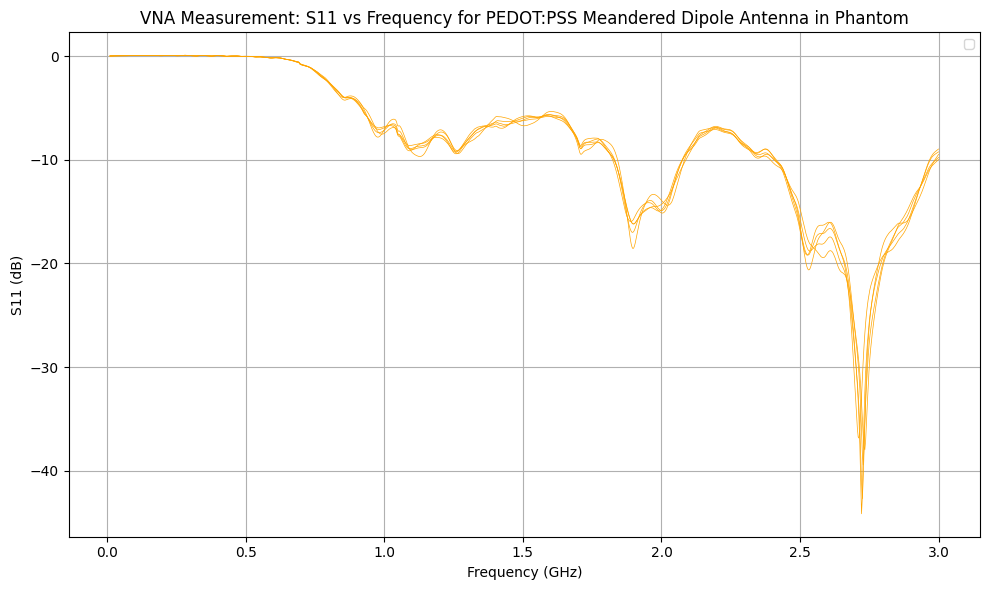

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# ------------------------------------------------
# Find all .s2p files in Google Colab working directory
# ------------------------------------------------
s2p_files = sorted(glob.glob("*.s2p"))

if not s2p_files:
    print("No .s2p files found.")
else:
    print(f"Found {len(s2p_files)} s2p files.")

    # ------------------------------------------------
    # Create ONE figure for all files
    # ------------------------------------------------
    plt.figure(figsize=(10, 6))

    # ------------------------------------------------
    # Process each S2P file
    # ------------------------------------------------
    for i, s2p_file in enumerate(s2p_files, start=1):

        freq = []
        s11_db = []

        # Default values
        freq_scale = 1
        data_format = 'DB'

        # ------------------------------------------------
        # Read S2P file
        # ------------------------------------------------
        with open(s2p_file, 'r') as f:
            for line in f:
                line = line.strip()

                # Skip empty lines and comments
                if not line or line.startswith('!'):
                    continue

                # Parse options line
                if line.startswith('#'):
                    option_line = line.upper()

                    # Frequency scaling
                    if 'GHZ' in option_line:
                        freq_scale = 1
                    elif 'MHZ' in option_line:
                        freq_scale = 1e-3
                    elif 'KHZ' in option_line:
                        freq_scale = 1e-6
                    elif 'HZ' in option_line:
                        freq_scale = 1e-9

                    # Data format
                    if 'DB' in option_line:
                        data_format = 'DB'
                    elif 'MA' in option_line:
                        data_format = 'MA'
                    elif 'RI' in option_line:
                        data_format = 'RI'

                    continue

                values = [float(v) for v in line.split()]

                # Frequency in GHz
                f_ghz = values[0] * freq_scale

                # Extract S11
                # Touchstone S2P order starts with S11, then S21, S12, S22
                if data_format == 'DB':
                    s11 = values[1]

                elif data_format == 'MA':
                    mag = values[1]
                    s11 = 20 * np.log10(mag)

                elif data_format == 'RI':
                    real = values[1]
                    imag = values[2]
                    mag = np.sqrt(real**2 + imag**2)
                    s11 = 20 * np.log10(mag)

                freq.append(f_ghz)
                s11_db.append(s11)

        freq = np.array(freq)
        s11_db = np.array(s11_db)

        # Use filename without extension as legend label
        file_name = os.path.splitext(os.path.basename(s2p_file))[0]

        # Plot onto the SAME graph
        plt.plot(
            freq,
            s11_db,
            linewidth=0.5,
            #label=f"VNA Measurement {i}",
            color="orange"
        )

    # ------------------------------------------------
    # Final formatting for combined plot
    # ------------------------------------------------
    plt.xlabel('Frequency (GHz)')
    plt.ylabel('S11 (dB)')
    plt.title('VNA Measurement: S11 vs Frequency for PEDOT:PSS Meandered Dipole Antenna in Phantom')
    plt.grid(True)
    plt.legend(fontsize=9)
    plt.tight_layout()

    # ------------------------------------------------
    # Save one combined figure
    # ------------------------------------------------
    output_name = "PEDOT_VNA_S11_overlay.png"
    plt.savefig(output_name, dpi=300, bbox_inches='tight')

    print(f"Saved: {output_name}")

    plt.show()
    plt.close()